# Creating Agents and Using Middleware With it

In [8]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langchain.messages import AIMessage,HumanMessage,SystemMessage
from langchain.agents.middleware import SummarizationMiddleware
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.tools import OpenWeatherMapQueryRun,WikipediaQueryRun,DuckDuckGoSearchRun
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv


load_dotenv()

True

In [ ]:
agent=create_agent(
    model=ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite'),
    tools=[OpenWeatherMapQueryRun(),DuckDuckGoSearchRun()],
    checkpointer=InMemorySaver(),
    system_prompt=SystemMessage(content='''You are a helpful agent.
You MUST use tools for:
- Any real-time information (weather, news, prices)
- Any location-based query
Do NOT guess. Always call tools when needed.'''),
    middleware=[SummarizationMiddleware(
        model=ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite'),
        trigger=("messages",5),
        keep=("messages",2)
    )],
)

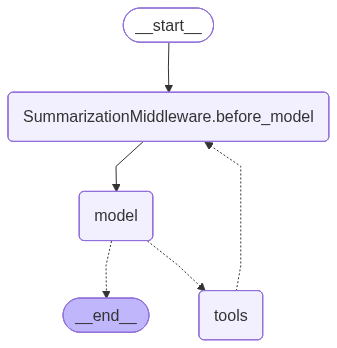

In [19]:
agent

In [20]:
config={"configurable":{"thread_id":"user-1"}}

In [21]:
questions = [
    "What is the current temperature and humidity in Hyderabad right now?",
    "Will it rain in Bangalore today? Give details for the next 6 hours.",
    "Compare today’s weather in Delhi and Mumbai — which city is hotter?",
    "What is the wind speed and visibility in Chennai currently?",
    "Give me a weather summary for my location today and suggest if I should carry an umbrella.",
    "What are the latest news updates about AI in 2026?",
    "Who won the most recent IPL match and what was the score?",
    "What are the current gold prices in India today?",
    "Find recent updates about OpenAI or Google Gemini models.",
    "What are the trending technologies in 2026 according to recent articles?",
    "Check today’s weather in Mumbai and tell me if any news mentions heavy rainfall there.",
    "Is there any weather alert in Delhi today? Also search if it’s in the news.",
    "Compare today’s temperature in Hyderabad with yesterday’s news about heatwaves."
]

In [22]:
for qus in questions:
    response=agent.invoke({'messages':[HumanMessage(content=qus)]},config=config)
    print(f'Agent: {response}')
    print(f'message: {len(response['messages'])}')

Agent: {'messages': [HumanMessage(content='What is the current temperature and humidity in Hyderabad right now?', additional_kwargs={}, response_metadata={}, id='0402aeae-ead1-4846-bb5b-23f589b540b5'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'open_weather_map', 'arguments': '{"location": "Hyderabad, India"}'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d6c79-9127-7072-92e9-834970da558c-0', tool_calls=[{'name': 'open_weather_map', 'args': {'location': 'Hyderabad, India'}, 'id': '144849c5-493b-4d8a-9bcb-9ffdd2a6eb63', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 191, 'output_tokens': 19, 'total_tokens': 210, 'input_token_details': {'cache_read': 0}}), ToolMessage(content='In Hyderabad, India, the current weather is as follows:\nDetailed status: few clouds\nWind speed: 4.12 m/s, direction: 290°\nHumidity: 18%\nTemperat

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash-lite' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash-lite\nPlease retry in 16.593714032s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerM